In [157]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import scipy as scipy

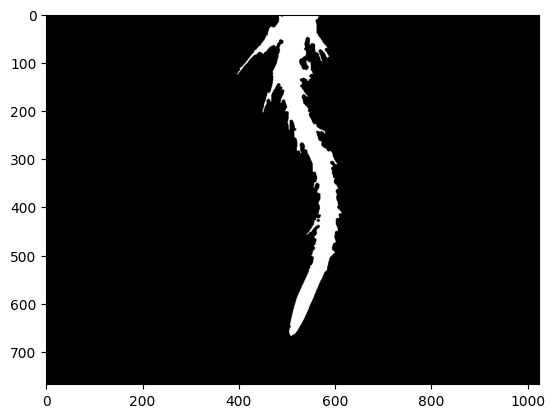

In [158]:
# import image
image_path = '/Users/antoantony/9-30/KO/KO 10 um T0/KO 10 um_1.bmp'
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# turn it black/white
_, mask = cv2.threshold(image_gray, 110, 255, cv2.THRESH_BINARY_INV)

# 4x4 kernel with adaptive threshold (this actually seems to make it worse, so maybe ignore this part)
# kernel4x4 = np.ones((4,4), np.uint8)
# adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 35, 8)
# # The last two numbers are the block size and the constant subtracted from the mean, respectively. You can adjust these parameters to see how they affect the result.
# adaptive_thresholded = cv2.morphologyEx(adapt, cv2.MORPH_OPEN, kernel4x4)

# connected component
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # Skip the background label

CC_mask = np.zeros_like(mask)
CC_mask[labels == largest_label] = 255

# Morphological closing to fill holes
kernel7x7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed_mask = cv2.morphologyEx(CC_mask, cv2.MORPH_CLOSE, kernel7x7)

contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_closed_contour = np.zeros_like(closed_mask)
cv2.drawContours(mask_closed_contour, contours, -1, 255, -1)

plt.imshow(mask_closed_contour, cmap='gray')
plt.show()

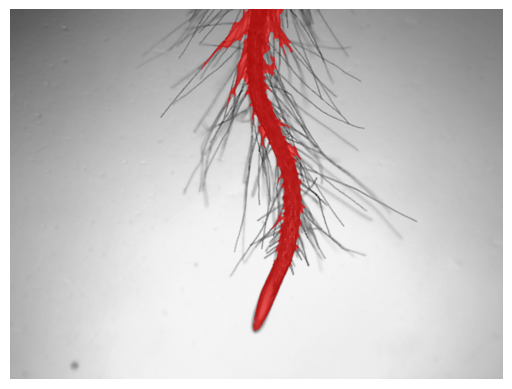

In [159]:
# Create overlay

img_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
mask_rgb = cv2.cvtColor(mask_closed_contour, cv2.COLOR_GRAY2RGB)

overlay = img_rgb.copy()
overlay[mask_closed_contour == 255] = [255, 0, 0]  # Red color for the mask area

alpha = 0.4  # Transparency factor
final_overlay = cv2.addWeighted(img_rgb, alpha, overlay, 1 - alpha, 0)

plt.imshow(final_overlay)
plt.axis('off')
plt.show()

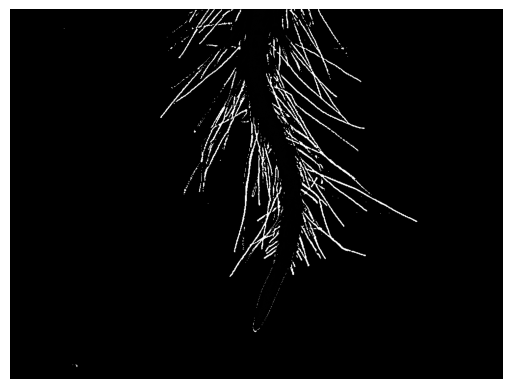

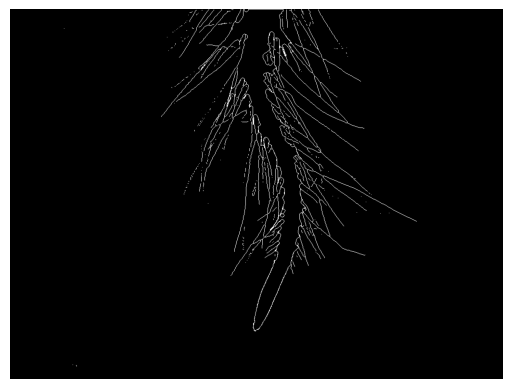

In [160]:
# Create new mask for root hairs using adaptive thresholding
better_adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 8)
root_hair_mask = better_adapt - mask_closed_contour

skeletonized = sk.morphology.skeletonize(root_hair_mask // 255)
skeletonized = (skeletonized * 255).astype(np.uint8)

cv2.drawContours(skeletonized, contours, -1, 255, 1)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(skeletonized, connectivity=8)


plt.imshow(root_hair_mask, cmap='gray')
plt.axis('off')
plt.show()
plt.imshow(skeletonized, cmap='gray')  
plt.axis('off')
plt.show()

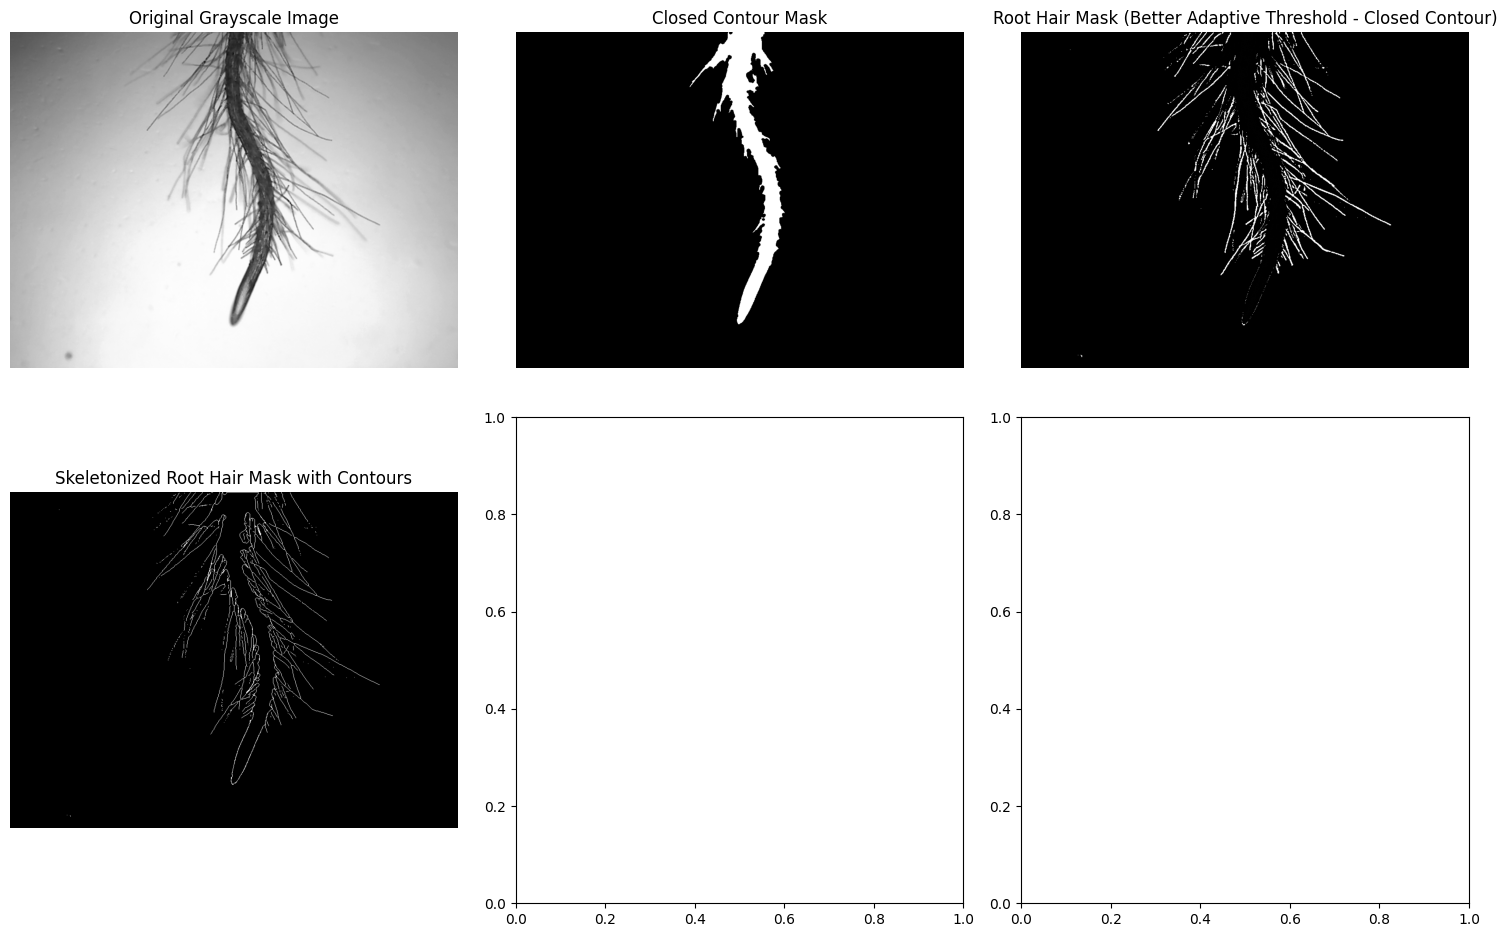

In [161]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original Grayscale Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(mask_closed_contour, cmap='gray')
ax[0, 1].set_title('Closed Contour Mask')
ax[0, 1].axis('off')
ax[0, 2].imshow(root_hair_mask, cmap='gray')
ax[0, 2].set_title('Root Hair Mask (Better Adaptive Threshold - Closed Contour)')
ax[0, 2].axis('off')
ax[1, 0].imshow(skeletonized, cmap='gray')
ax[1, 0].set_title('Skeletonized Root Hair Mask with Contours')
ax[1, 0].axis('off')
plt.tight_layout()
plt.show()